In [79]:
import pandas as pd

# 1. Import the dataset (replace 'your_data.csv' with your actual file path)
df = pd.read_csv('/Users/deepakkushwaha/Library/CloudStorage/GoogleDrive-deepakkushwaha771@gmail.com/My Drive/Data Science/DS Projects/MY Projects/Public transpor/public_transport_delays.csv')

# 2. Display the first 5 rows
print("--- FIRST 5 ROWS ---")
display(df.head())

# 3. What are the variable names and their data types?
print("\n--- DATA TYPES ---")
# 'object' usually means categorical/text, 'int64'/'float64' means numeric
print(df.dtypes)

--- FIRST 5 ROWS ---


,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1



--- DATA TYPES ---
trip_id                        object
date                           object
time                           object
transport_type                 object
route_id                       object
origin_station                 object
destination_station            object
scheduled_departure            object
scheduled_arrival              object
actual_departure_delay_min      int64
actual_arrival_delay_min        int64
weather_condition              object
temperature_C                 float64
humidity_percent                int64
wind_speed_kmh                  int64
precipitation_mm              float64
event_type                     object
event_attendance_est            int64
traffic_congestion_index        int64
holiday                         int64
peak_hour                       int64
weekday                         int64
season                         object
delayed                         int64
dtype: object


In [80]:
# Check the dimensions of the dataset
observations, variables = df.shape

print(f"Total Observations (Rows): {observations}")
print(f"Total Variables (Columns): {variables}")

Total Observations (Rows): 2000
Total Variables (Columns): 24


In [81]:
# Calculate the total missing values per column
missing_counts = df.isnull().sum()

# Calculate the proportion (percentage) of missing values per column
missing_proportions = (df.isnull().mean() * 100).round(2)

# Combine them into a clean dataframe for easy reading
missing_summary = pd.DataFrame({
    'Missing Values': missing_counts,
    'Percentage (%)': missing_proportions
})

# Filter to show ONLY columns that actually have missing values
missing_summary = missing_summary[missing_summary['Missing Values'] > 0]

print("--- MISSING VALUES SUMMARY ---")
if not missing_summary.empty:
    display(missing_summary.sort_values(by='Percentage (%)', ascending=False))
else:
    print("No missing values found in the dataset!")

--- MISSING VALUES SUMMARY ---


,Missing Values,Percentage (%)
event_type,1173,58.65


In [82]:
import pandas as pd

# 1. Fill the missing values in 'event_type' with "No_Event"
df['event_type'] = df['event_type'].fillna('No_Event')

# 2. Verify that the missing values have been handled
missing_after = df.isnull().sum().sum()
print(f"Total missing values remaining in dataset: {missing_after}")

# 3. Check the shape to confirm we haven't dropped any columns
print(f"Current Dataset Shape: {df.shape}")

Total missing values remaining in dataset: 0
Current Dataset Shape: (2000, 24)


In [83]:
import pandas as pd

print("=========================================")
print(" 1. NUMERIC VARIABLES: DESCRIPTIVE STATS ")
print("=========================================")
# .describe() automatically calculates mean, std, min, max, and quartiles (including the median at 50%)
numeric_stats = df_cleaned.describe()
display(numeric_stats)

print("\n=========================================")
print(" 2. CATEGORICAL VARIABLES: FREQUENCY TABLES")
print("=========================================")
# Select only the text/object columns
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

# Loop through each category and print its frequency table
for col in categorical_cols:
    print(f"\n--- {col.upper()} ---")
    # .value_counts() counts how many times each category appears
    # normalize=True gives you the percentage (optional, but helpful!)
    counts = df_cleaned[col].value_counts()
    percentages = (df_cleaned[col].value_counts(normalize=True) * 100).round(1)
    
    # Combine into a nice table
    freq_table = pd.DataFrame({'Count': counts, 'Percentage (%)': percentages})
    display(freq_table)

 1. NUMERIC VARIABLES: DESCRIPTIVE STATS 


,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,delayed,storm_peak,heavy_rain,high_congestion
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,15.121350,64.714000,29.300500,9.860700,6420.250000,50.244000,0.089500,0.272000,2.976000,0.749500,0.052000,0.484000,0.317000
std,11.479424,20.334747,17.264015,5.781373,15198.306129,29.225751,0.285535,0.445101,1.990328,0.433409,0.222083,0.499869,0.465424
min,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.100000,46.000000,15.000000,4.900000,0.000000,25.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,15.300000,65.000000,29.000000,9.700000,0.000000,50.000000,0.000000,0.000000,3.000000,1.000000,0.000000,0.000000,0.000000
75%,24.800000,83.000000,45.000000,14.800000,2000.000000,76.000000,0.000000,1.000000,5.000000,1.000000,0.000000,1.000000,1.000000
max,35.000000,99.000000,59.000000,20.000000,50000.000000,99.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,1.000000



 2. CATEGORICAL VARIABLES: FREQUENCY TABLES

--- TRANSPORT_TYPE ---


,Count,Percentage (%)
transport_type,,
Bus,525,26.2
Train,493,24.6
Tram,491,24.6
Metro,491,24.6



--- ROUTE_ID ---


...

,Count,Percentage (%)
weather_condition,,
Clear,343,17.2
Snow,343,17.2
Storm,337,16.8
Fog,331,16.6
Cloudy,325,16.2
Rain,321,16.0



--- EVENT_TYPE ---


,Count,Percentage (%)
event_type,,
No_Event,1173,58.6
Festival,221,11.0
Sports,212,10.6
Concert,203,10.2
Parade,105,5.2
Protest,86,4.3



--- SEASON ---


,Count,Percentage (%)
season,,
Summer,524,26.2
Spring,502,25.1
Winter,494,24.7
Autumn,480,24.0


 3. NUMERIC PLOTS: HISTOGRAMS & BOXPLOTS 


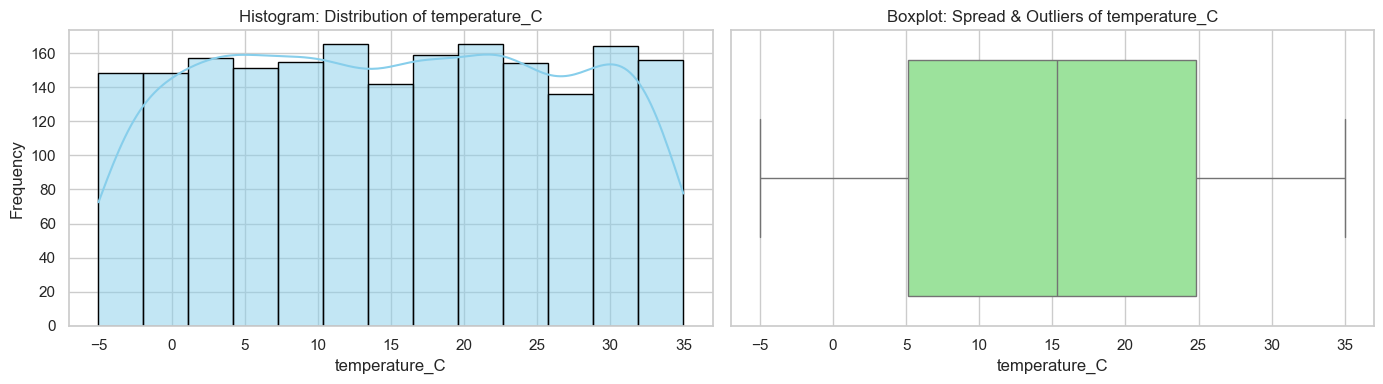

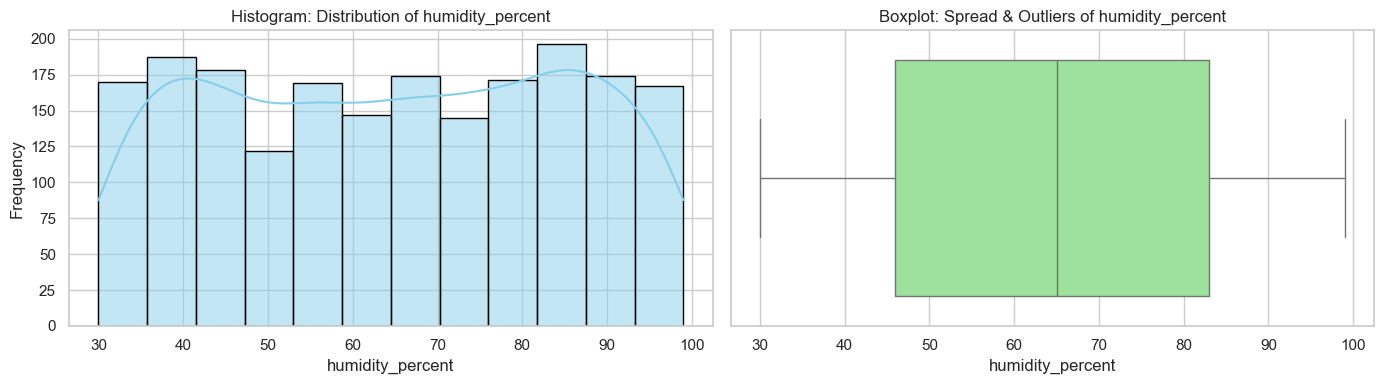

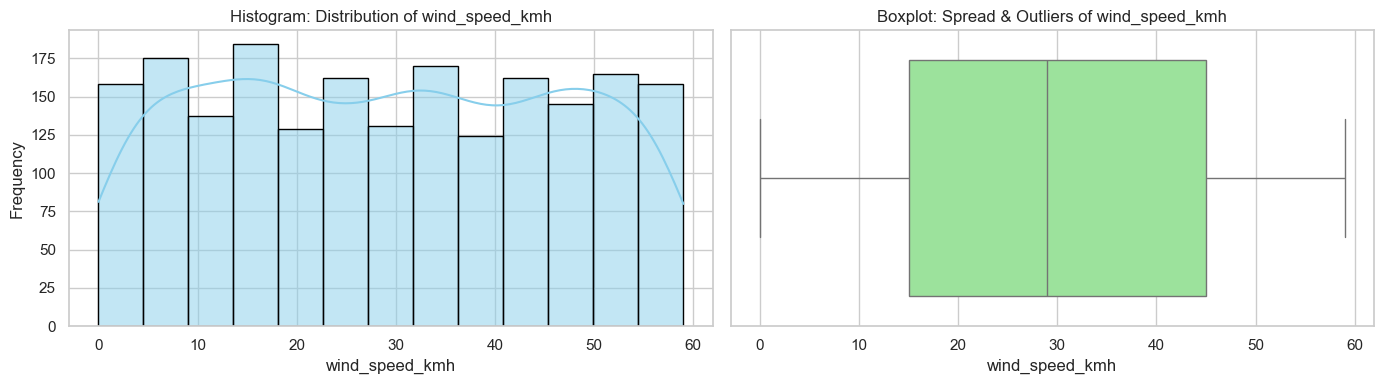

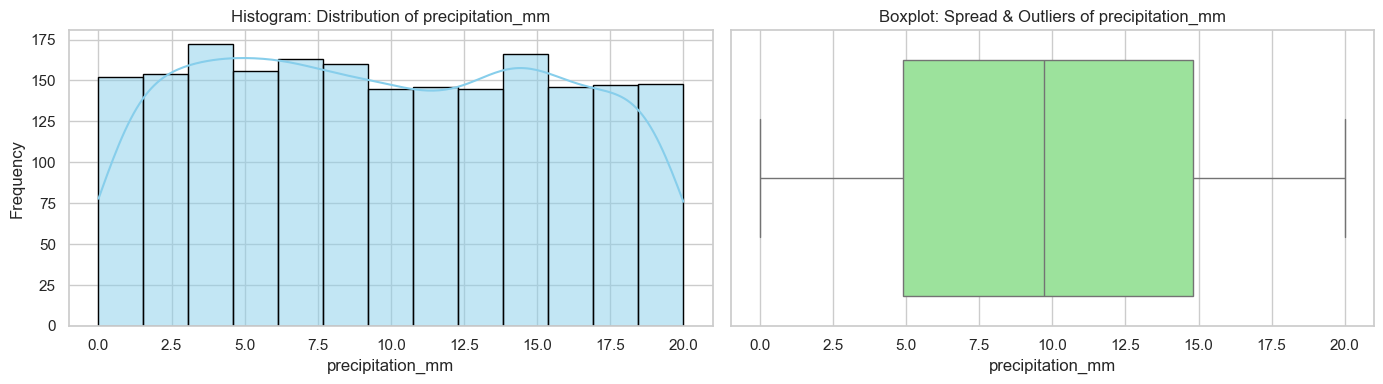

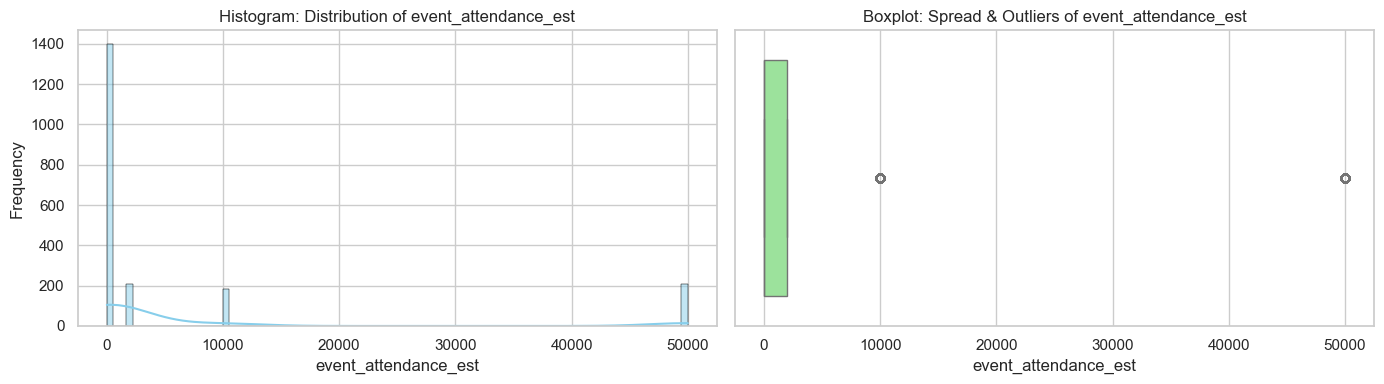

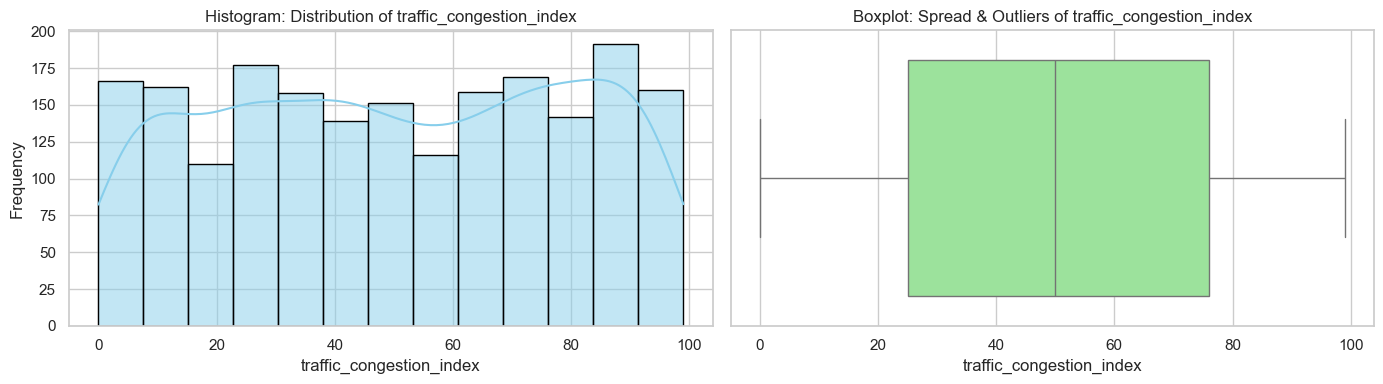

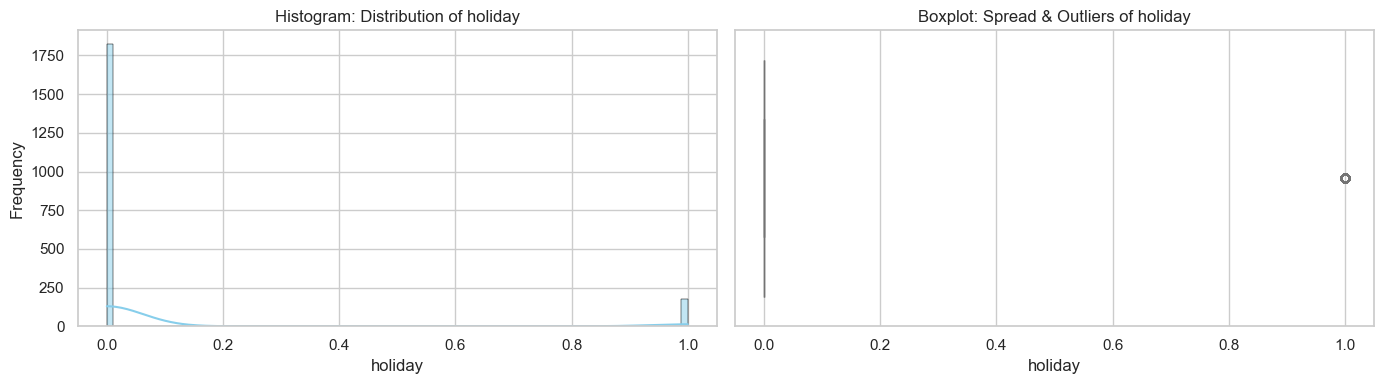

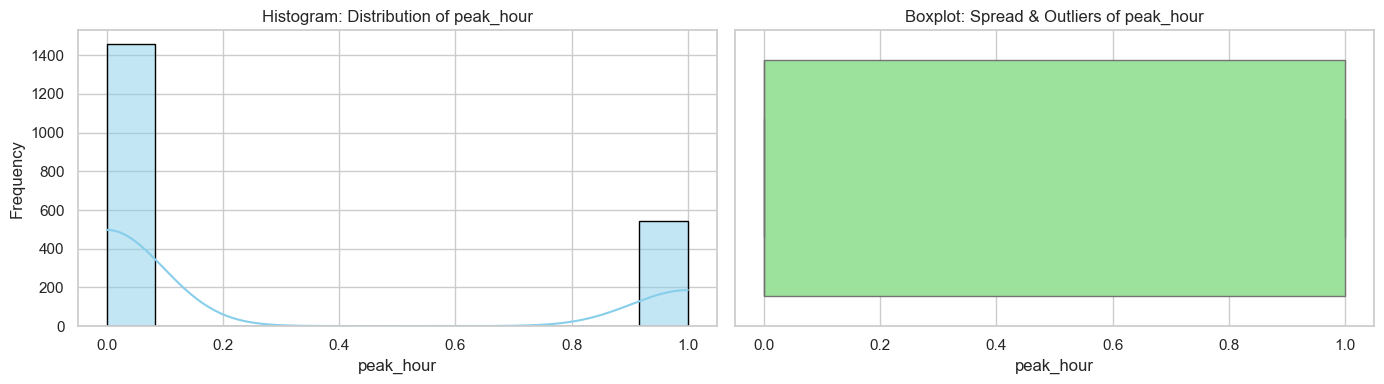

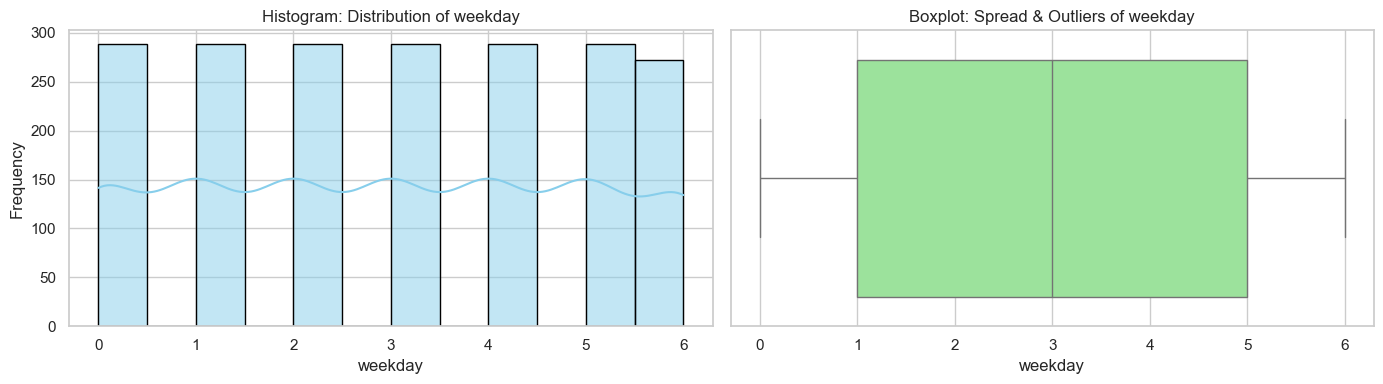

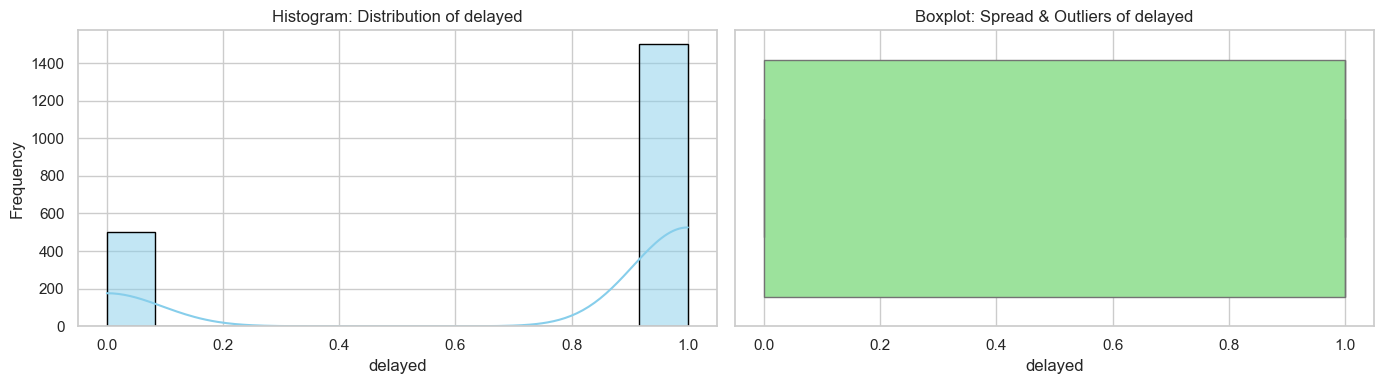

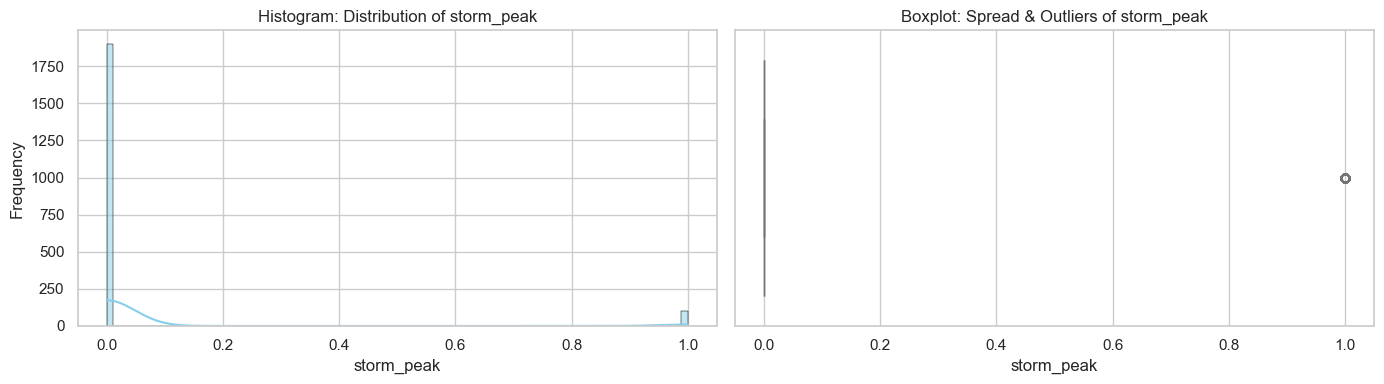

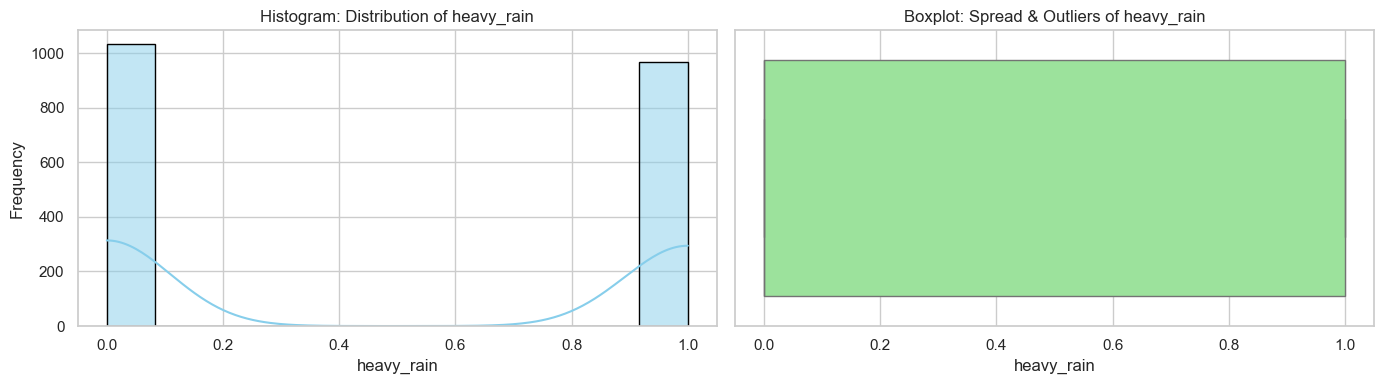

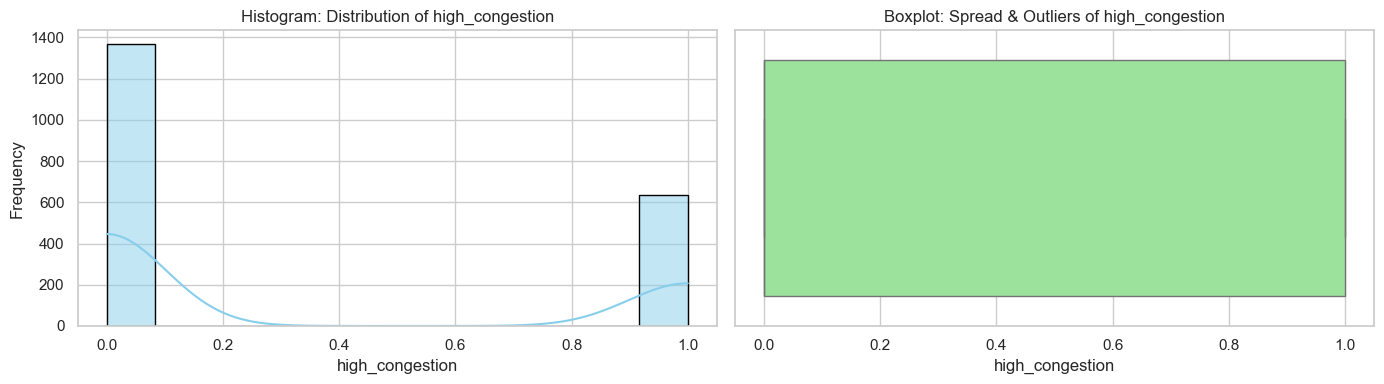

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style for the plots
sns.set_theme(style="whitegrid")

numeric_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns

print("=========================================")
print(" 3. NUMERIC PLOTS: HISTOGRAMS & BOXPLOTS ")
print("=========================================")

# Loop through each numeric column and create a side-by-side Histogram and Boxplot
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4)) # 1 row, 2 columns
    
    # Left Plot: Histogram with a KDE (Kernel Density Estimate) curve to show shape
    sns.histplot(df_cleaned[col], kde=True, ax=axes[0], color='skyblue', edgecolor='black')
    axes[0].set_title(f'Histogram: Distribution of {col}')
    axes[0].set_ylabel('Frequency')
    
    # Right Plot: Boxplot to show spread and outliers
    sns.boxplot(x=df_cleaned[col], ax=axes[1], color='lightgreen')
    axes[1].set_title(f'Boxplot: Spread & Outliers of {col}')
    
    plt.tight_layout()
    plt.show()

 4. CATEGORICAL PLOTS: BAR CHARTS        


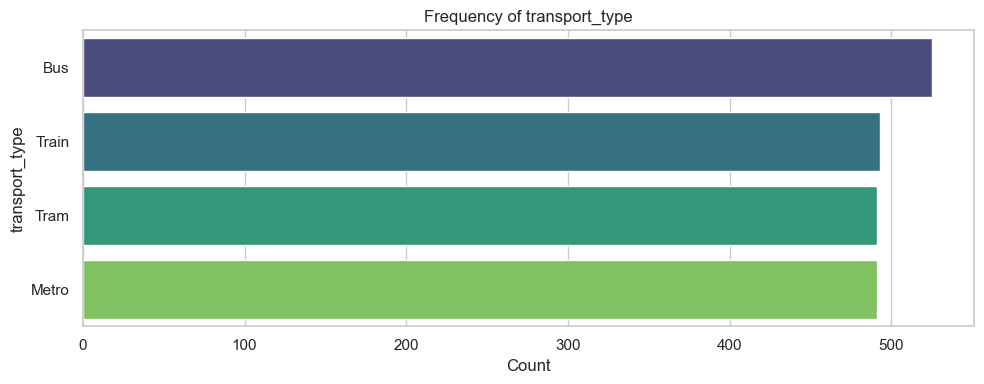

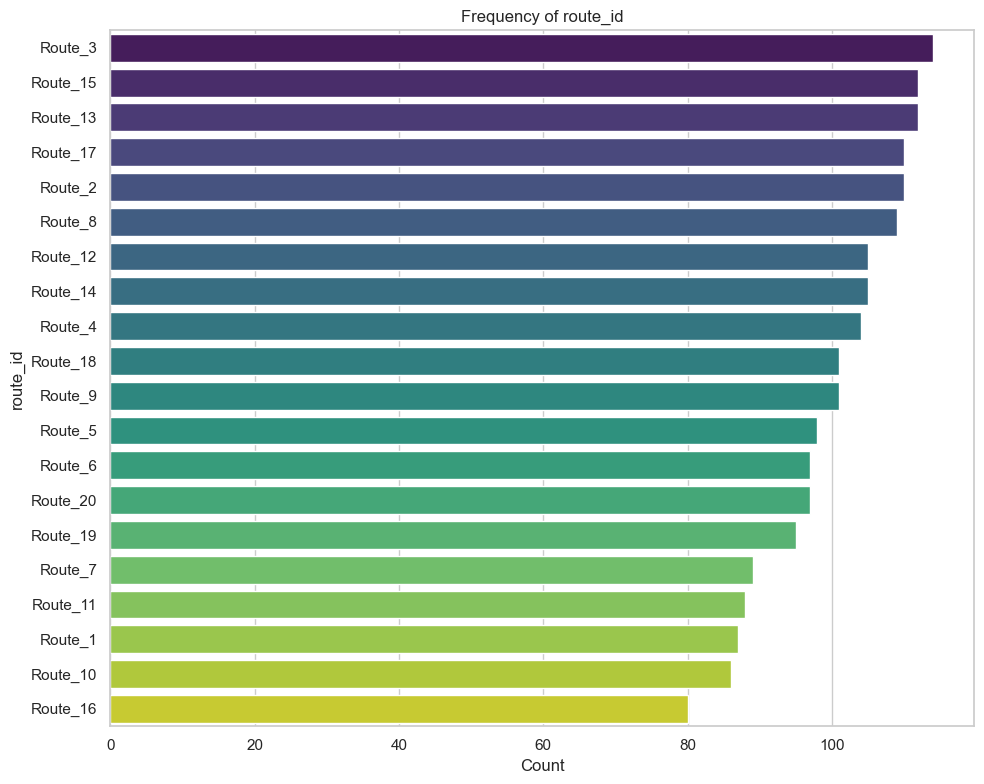

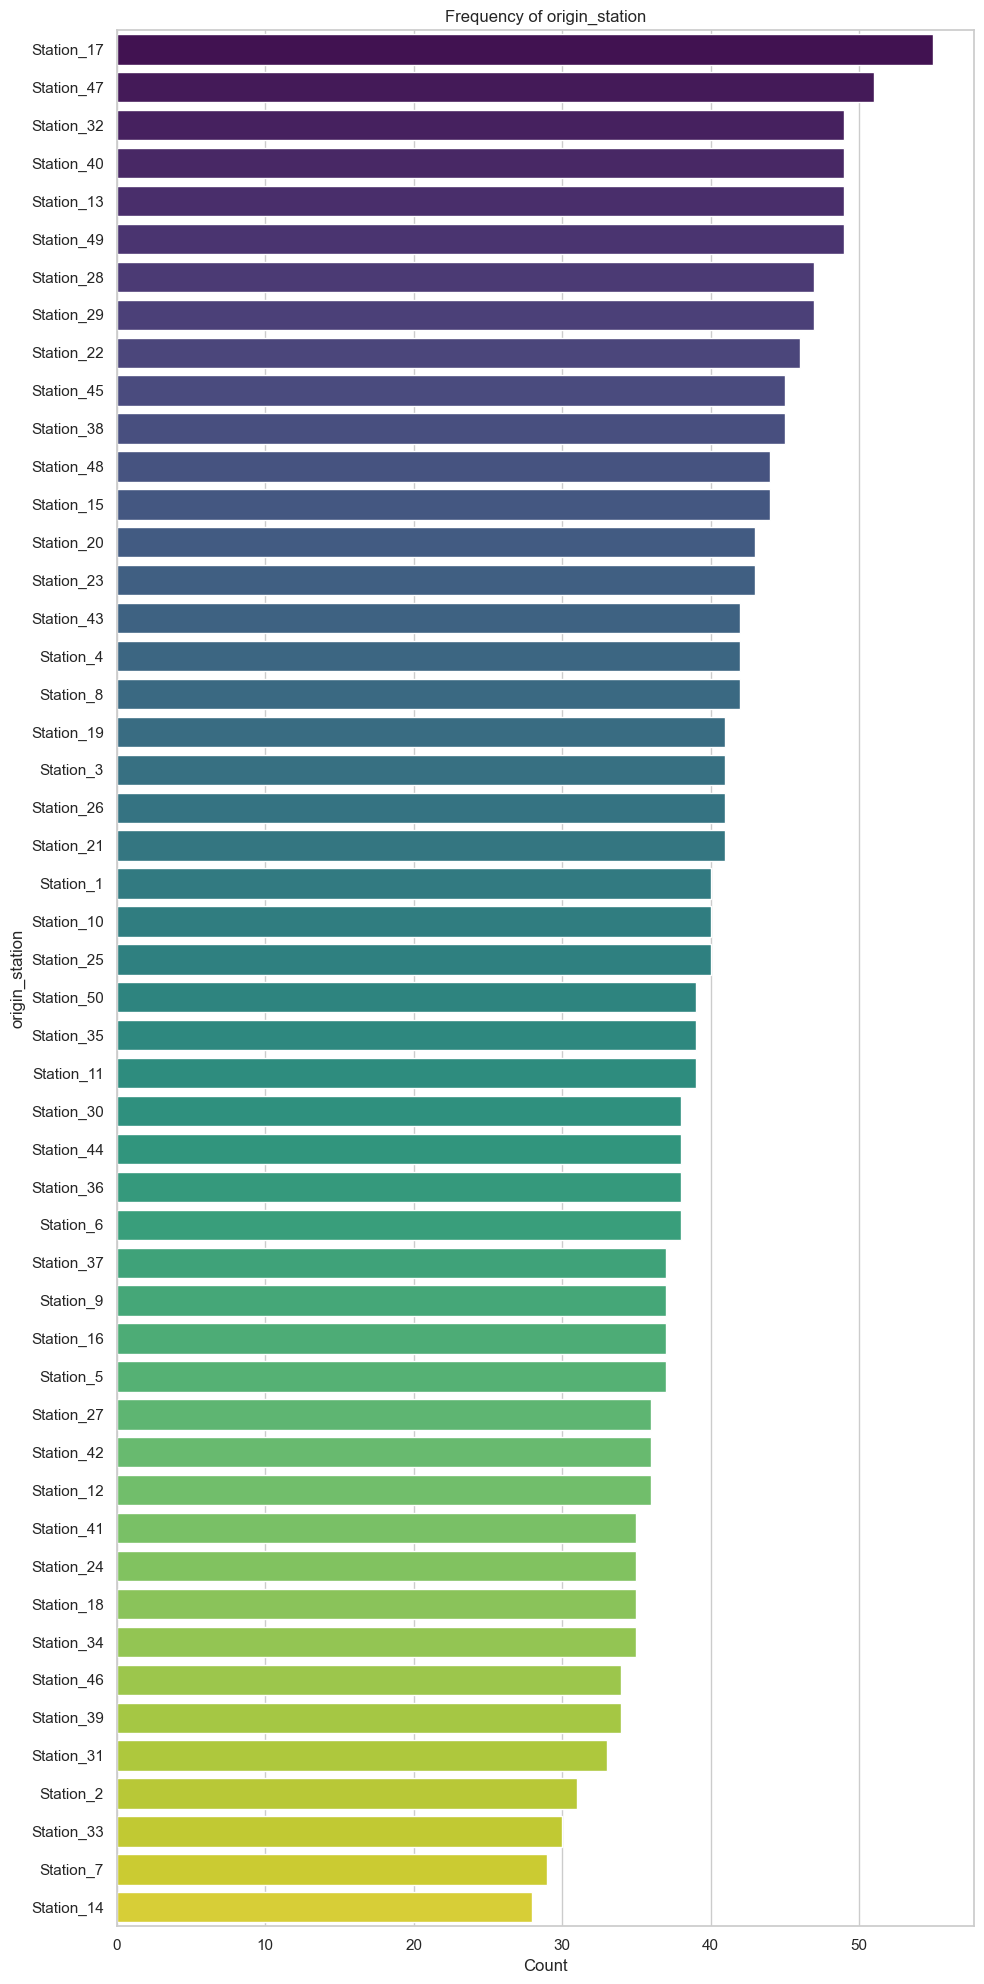

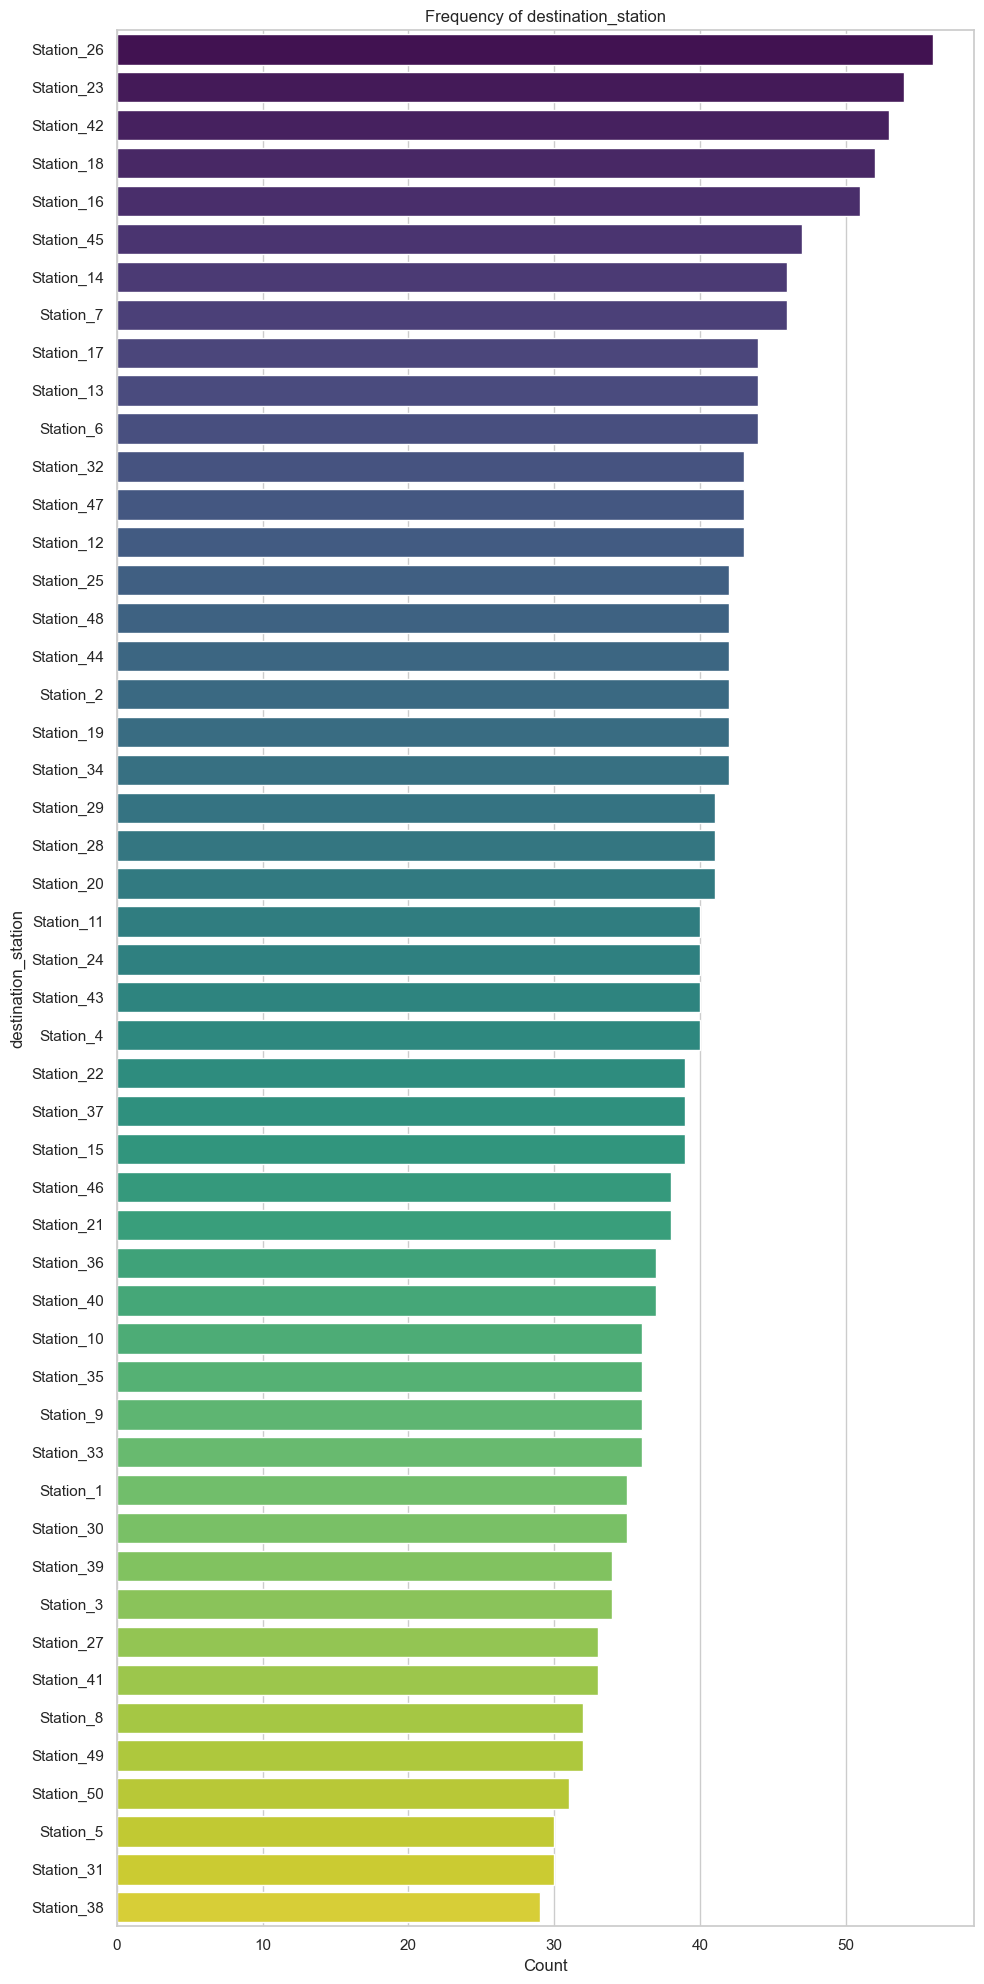

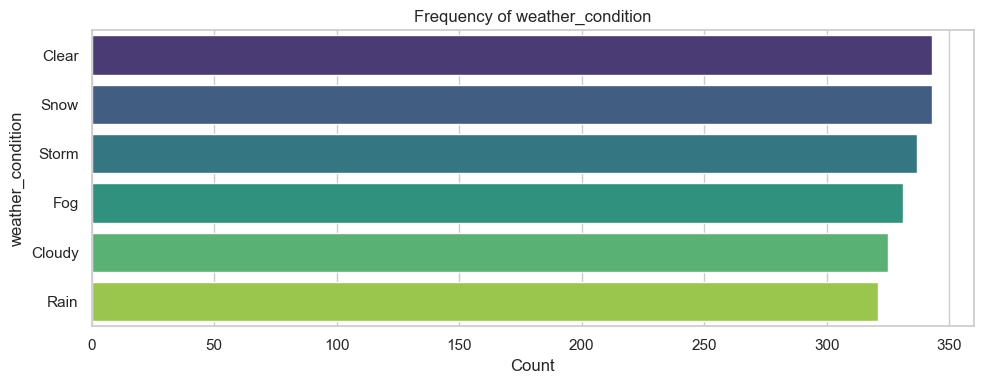

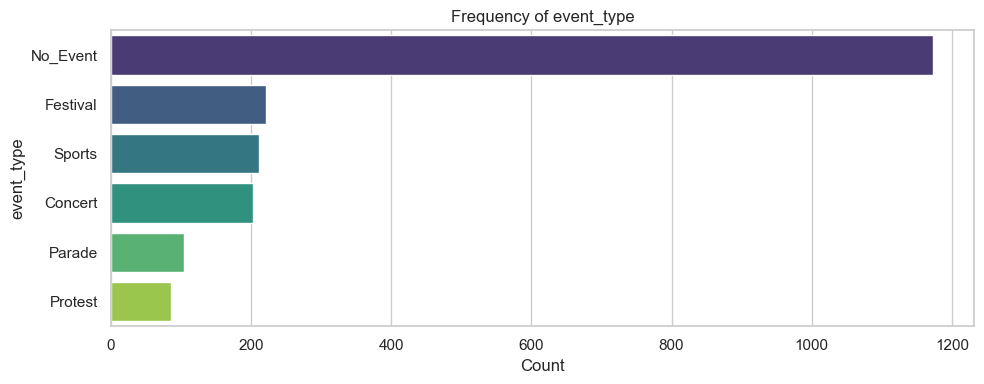

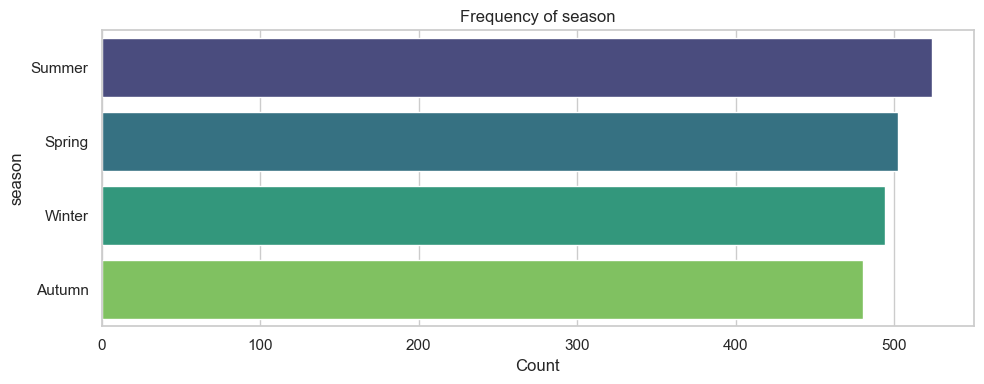

In [85]:
print("=========================================")
print(" 4. CATEGORICAL PLOTS: BAR CHARTS        ")
print("=========================================")

for col in categorical_cols:
    # Adjust the height of the plot depending on how many categories there are
    num_unique = df_cleaned[col].nunique()
    plt.figure(figsize=(10, max(4, num_unique * 0.4))) 
    
    # Create a horizontal bar chart, ordered from most frequent to least frequent
    sns.countplot(
        data=df_cleaned, 
        y=col, 
        order=df_cleaned[col].value_counts().index, 
        palette='viridis'
    )
    
    plt.title(f'Frequency of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

--- COMPUTING CORRELATION MATRIX ---


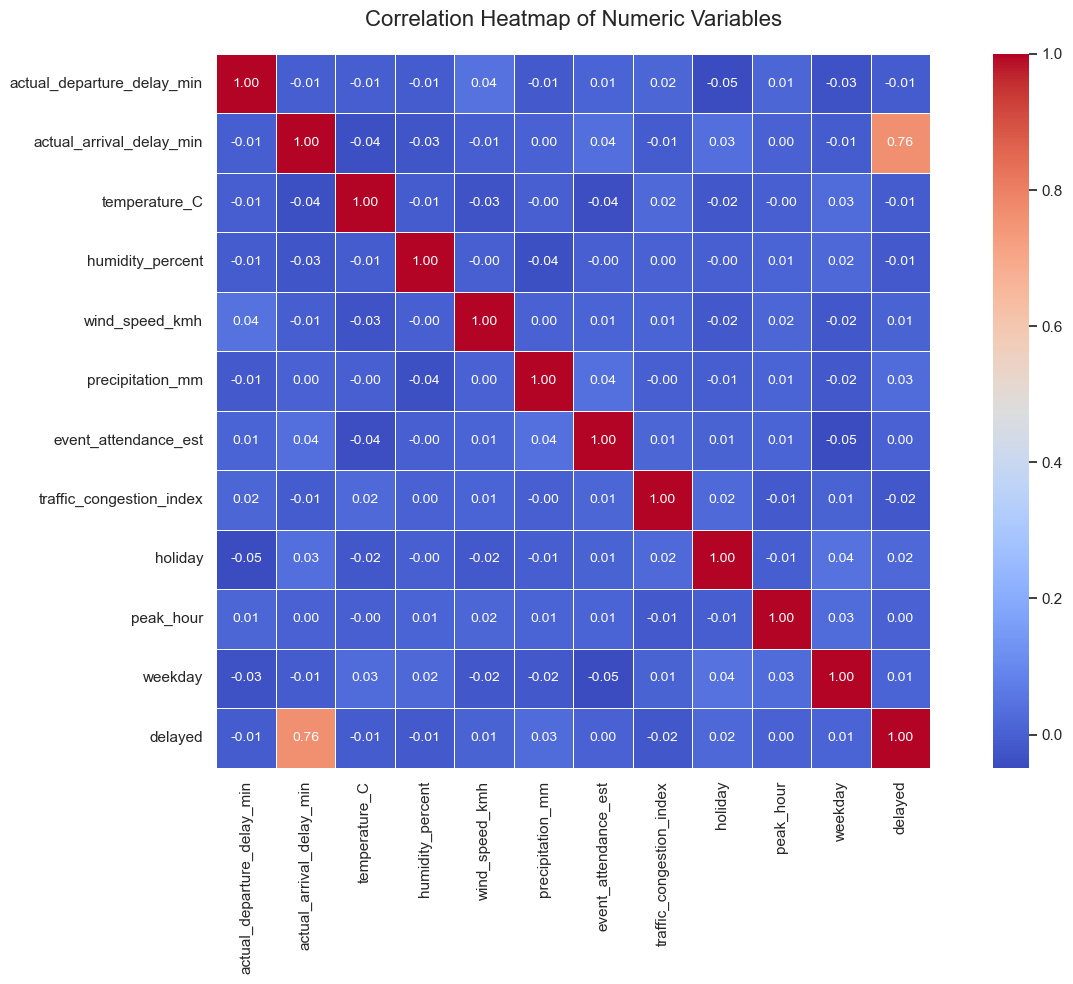

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- COMPUTING CORRELATION MATRIX ---")

# 1. Isolate the numeric columns 
# (Correlation math only works on numbers, so we must filter out the text/object columns first)
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# 2. Compute the correlation matrix using Pearson's method (the standard)
corr_matrix = numeric_df.corr()

# 3. Set up the visualization
plt.figure(figsize=(14, 10)) # Make the figure large enough to read clearly

# 4. Generate the Heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,           # Show the actual correlation numbers in the boxes
    fmt=".2f",            # Format the numbers to 2 decimal places
    cmap="coolwarm",      # Coolwarm is best: Blue = negative, Red = positive, White = zero
    cbar=True,            # Show the color scale bar on the right
    square=True,          # Make the grid cells perfectly square
    linewidths=0.5,       # Add thin grid lines between cells to make it readable
    annot_kws={"size": 10}# Make the text inside the boxes a bit smaller
)

# 5. Add titles and render
plt.title("Correlation Heatmap of Numeric Variables", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

--- SCATTERPLOTS (NUMERIC VS NUMERIC) ---


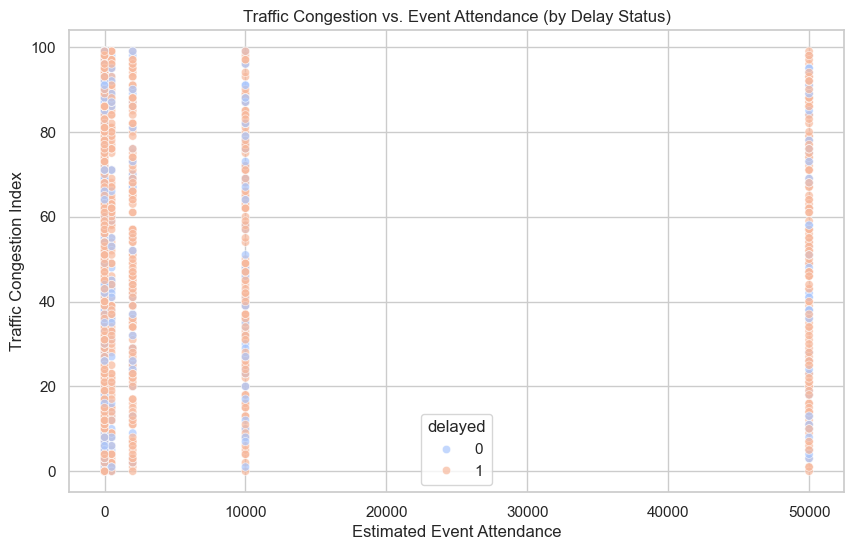

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
print("--- SCATTERPLOTS (NUMERIC VS NUMERIC) ---")

# Let's look at Traffic vs. Event Attendance
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='event_attendance_est', 
    y='traffic_congestion_index', 
    hue='delayed', 
    palette='coolwarm', 
    alpha=0.7 # Makes dots slightly transparent to see overlapping points
)
plt.title("Traffic Congestion vs. Event Attendance (by Delay Status)")
plt.xlabel("Estimated Event Attendance")
plt.ylabel("Traffic Congestion Index")
plt.show()

# Alternatively, if you want to quickly see scatterplots for ALL numeric pairs at once:
# (Warning: This takes a minute to render if you have many numeric columns!)
# sns.pairplot(df[['temperature_C', 'humidity_percent', 'wind_speed_kmh', 'delayed']], hue='delayed')
# plt.show()


--- DISTRIBUTIONS ACROSS CATEGORIES ---


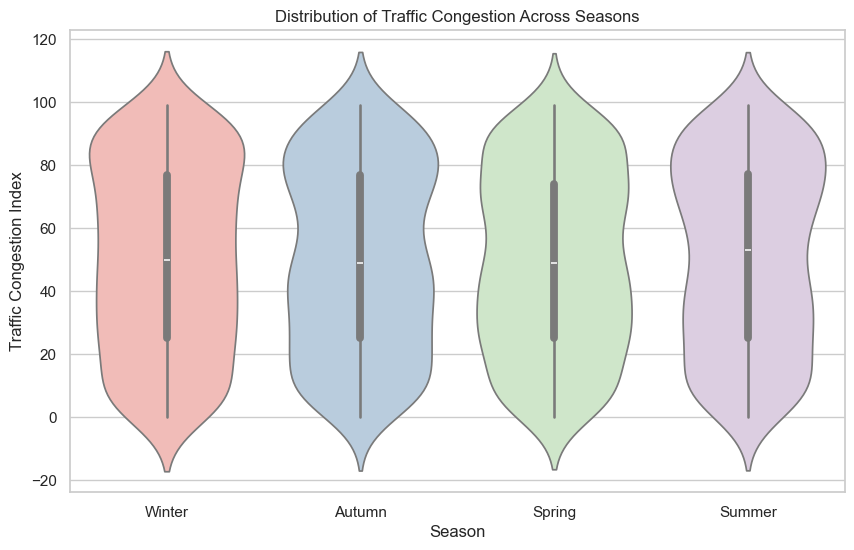

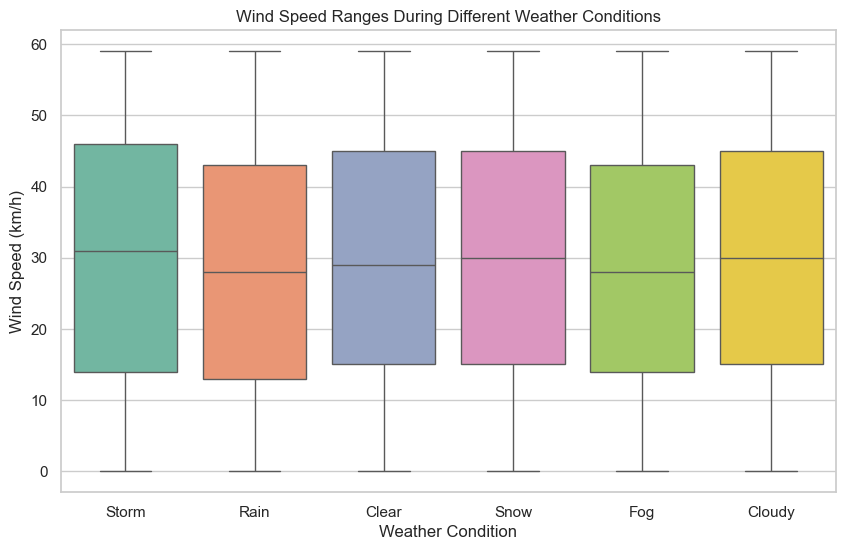

In [88]:
print("\n--- DISTRIBUTIONS ACROSS CATEGORIES ---")

# Let's compare Traffic Congestion across different Seasons
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=df, 
    x='season', 
    y='traffic_congestion_index', 
    palette='Pastel1'
)
plt.title("Distribution of Traffic Congestion Across Seasons")
plt.xlabel("Season")
plt.ylabel("Traffic Congestion Index")
plt.show()

# Let's compare Wind Speed across Weather Conditions
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df, 
    x='weather_condition', 
    y='wind_speed_kmh', 
    palette='Set2'
)
plt.title("Wind Speed Ranges During Different Weather Conditions")
plt.xlabel("Weather Condition")
plt.ylabel("Wind Speed (km/h)")
plt.show()

In [89]:
print("\n--- CONTINGENCY TABLES (CATEGORICAL VS CATEGORICAL) ---")

# Let's see how Weather Condition interacts with Delays
# margins=True adds "All" totals to the rows and columns
contingency_table = pd.crosstab(
    df['weather_condition'], 
    df['delayed'], 
    margins=True, 
    margins_name="Total"
)

print("Contingency Table: Weather vs. Delays\n")
display(contingency_table)

# To make it even easier to read, let's look at the PERCENTAGES instead of raw counts
# normalize='index' shows what percentage of each weather condition resulted in a delay
contingency_pct = pd.crosstab(
    df['weather_condition'], 
    df['delayed'], 
    normalize='index'
) * 100

print("\nPercentage Breakdown (Row-wise):\n")
display(contingency_pct.round(1)) # Round to 1 decimal place


--- CONTINGENCY TABLES (CATEGORICAL VS CATEGORICAL) ---
Contingency Table: Weather vs. Delays



delayed,0,1,Total
weather_condition,,,
Clear,84,259,343
Cloudy,86,239,325
Fog,89,242,331
Rain,78,243,321
Snow,85,258,343
Storm,79,258,337
Total,501,1499,2000



Percentage Breakdown (Row-wise):



delayed,0,1
weather_condition,,
Clear,24.5,75.5
Cloudy,26.5,73.5
Fog,26.9,73.1
Rain,24.3,75.7
Snow,24.8,75.2
Storm,23.4,76.6


In [90]:
import pandas as pd

# 1. Define the exact list of columns that will ruin the model or are redundant
columns_to_drop = [
    'actual_departure_delay_min', # Data Leak!
    'actual_arrival_delay_min',   # Data Leak!
    'trip_id',                    # Pure identifier (causes overfitting)
    'date',                       # Raw string (we already have weekday, holiday, season)
    'time',                       # Raw string (we already have peak_hour)
    'scheduled_departure',        # Redundant raw string
    'scheduled_arrival'           # Redundant raw string
]

# 2. Drop these columns from your dataframe to create your finalized, clean dataset
# Note: Ensure you are using the dataframe where you already filled the 'event_type' missing values!
df_cleaned = df.drop(columns=columns_to_drop)

# 3. Verify the drop was successful
print("✅ Danger columns removed successfully!")
print(f"New Dataset Shape: {df_cleaned.shape}")

✅ Danger columns removed successfully!
New Dataset Shape: (2000, 17)


In [91]:
df_cleaned.head()

,transport_type,route_id,origin_station,destination_station,weather_condition,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,Tram,Route_15,Station_31,Station_6,Storm,5.1,52,46,13.0,No_Event,500,81,0,1,6,Winter,0
1,Metro,Route_12,Station_49,Station_32,Rain,34.0,64,11,11.4,No_Event,0,53,0,0,6,Autumn,1
2,Bus,Route_16,Station_29,Station_42,Clear,29.5,35,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,Tram,Route_19,Station_26,Station_18,Clear,27.4,55,41,6.4,No_Event,500,84,0,0,6,Winter,1
4,Tram,Route_8,Station_18,Station_15,Snow,0.1,90,30,18.5,No_Event,500,46,0,0,6,Spring,1


In [92]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

# ── 1. CHECK CARDINALITY ────────────────────────────────────────────────────
print("Cardinality of categorical columns:")
cat_cols = df_cleaned.select_dtypes(include='object').columns
for col in cat_cols:
    print(f"  {col}: {df_cleaned[col].nunique()} unique values")

Cardinality of categorical columns:
  transport_type: 4 unique values
  route_id: 20 unique values
  origin_station: 50 unique values
  destination_station: 50 unique values
  weather_condition: 6 unique values
  event_type: 6 unique values
  season: 4 unique values


In [93]:
# ── 2. SEPARATE FEATURES & TARGET ──────────────────────────────────────────
# Drop route_id (high cardinality, no predictive benefit over stations)
df_model = df_cleaned.drop(columns=['route_id'])

X = df_model.drop(columns=['delayed'])
y = df_model['delayed']

# ── 3. DEFINE COLUMN GROUPS ─────────────────────────────────────────────────
low_card_cat = ['transport_type', 'weather_condition', 'event_type', 'season']

high_card_cat = ['origin_station', 'destination_station']  # frequency encode

numeric_cols  = ['temperature_C', 'humidity_percent', 'wind_speed_kmh',
                 'precipitation_mm', 'event_attendance_est',
                 'traffic_congestion_index']

binary_cols   = ['holiday', 'peak_hour', 'weekday']  # already 0/1, keep as-is

print(f"\nFeature groups:")
print(f"  One-Hot  : {low_card_cat}")
print(f"  Freq Enc : {high_card_cat}")
print(f"  Numeric  : {numeric_cols}")
print(f"  Binary   : {binary_cols}")


Feature groups:
  One-Hot  : ['transport_type', 'weather_condition', 'event_type', 'season']
  Freq Enc : ['origin_station', 'destination_station']
  Numeric  : ['temperature_C', 'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_attendance_est', 'traffic_congestion_index']
  Binary   : ['holiday', 'peak_hour', 'weekday']


In [94]:
# ── 4. TRAIN-TEST SPLIT (before any encoding/SMOTE) ─────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserves class ratio in both splits
)

print(f"\nTrain size : {X_train.shape[0]} rows")
print(f"Test  size : {X_test.shape[0]} rows")
print(f"\nClass distribution (train):\n{y_train.value_counts(normalize=True).round(3)}")


Train size : 1600 rows
Test  size : 400 rows

Class distribution (train):
delayed
1    0.749
0    0.251
Name: proportion, dtype: float64


In [95]:
# ── 5. FREQUENCY ENCODING (fit on train only → apply to both) ───────────────
for col in high_card_cat:
    freq_map = X_train[col].value_counts(normalize=True).to_dict()
    X_train[col] = X_train[col].map(freq_map)
    X_test[col]  = X_test[col].map(freq_map).fillna(0)  # unseen → 0

print("Frequency encoding applied to:", high_card_cat)

Frequency encoding applied to: ['origin_station', 'destination_station']


In [96]:
# ── 6. COLUMN TRANSFORMER (One-Hot + StandardScaler) ────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('ohe',    OneHotEncoder(handle_unknown='ignore', sparse_output=False), low_card_cat),
    ('scaler', StandardScaler(),                                            numeric_cols + high_card_cat),
    ('passthrough', 'passthrough',                                          binary_cols)
], remainder='drop')

X_train_proc = preprocessor.fit_transform(X_train)   # fit ONLY on train
X_test_proc  = preprocessor.transform(X_test)        # apply to test

# Recover feature names for inspection
ohe_cols   = preprocessor.named_transformers_['ohe'].get_feature_names_out(low_card_cat).tolist()
final_cols = ohe_cols + numeric_cols + high_card_cat + binary_cols

X_train_proc = pd.DataFrame(X_train_proc, columns=final_cols)
X_test_proc  = pd.DataFrame(X_test_proc,  columns=final_cols)

print(f"\nShape after preprocessing → Train: {X_train_proc.shape}, Test: {X_test_proc.shape}")
print(f"Total features: {X_train_proc.shape[1]}")


Shape after preprocessing → Train: (1600, 31), Test: (400, 31)
Total features: 31


In [97]:
# ── 7. SMOTE (applied ONLY on training data) ─────────────────────────────────
print(f"\nBefore SMOTE → {y_train.value_counts().to_dict()}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)

print(f"After  SMOTE → {pd.Series(y_train_bal).value_counts().to_dict()}")
print(f"New train size: {X_train_bal.shape[0]} rows")


Before SMOTE → {1: 1199, 0: 401}
After  SMOTE → {1: 1199, 0: 1199}
New train size: 2398 rows


In [98]:
# ── 8. FINAL SUMMARY ────────────────────────────────────────────────────────
print("\n" + "="*50)
print("PIPELINE COMPLETE — Ready for modelling")
print("="*50)
print(f"  X_train_bal : {X_train_bal.shape}  ← use this to train")
print(f"  y_train_bal : {y_train_bal.shape}")
print(f"  X_test_proc : {X_test_proc.shape}   ← use this to evaluate")
print(f"  y_test      : {y_test.shape}")


PIPELINE COMPLETE — Ready for modelling
  X_train_bal : (2398, 31)  ← use this to train
  y_train_bal : (2398,)
  X_test_proc : (400, 31)   ← use this to evaluate
  y_test      : (400,)


In [99]:
# ── 1. IMPORTS ───────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [100]:
# ── 2. DEFINE MODELS ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42,
                                         eval_metric='logloss', verbosity=0)
}

In [101]:
# ── 3. TRAIN & EVALUATE ALL MODELS ──────────────────────────────────────────
results = []

for name, model in models.items():
    # Train
    model.fit(X_train_bal, y_train_bal)

    # Predict
    y_pred      = model.predict(X_test_proc)
    y_pred_prob = model.predict_proba(X_test_proc)[:, 1]

    # Metrics
    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall'   : round(recall_score(y_test, y_pred), 4),
        'F1 Score' : round(f1_score(y_test, y_pred), 4),
        'ROC-AUC'  : round(roc_auc_score(y_test, y_pred_prob), 4)
    })
    print(f"✓ {name} done")

results_df = pd.DataFrame(results).sort_values('F1 Score', ascending=False)
print("\n")
print(results_df.to_string(index=False))

✓ Logistic Regression done
✓ Decision Tree done
✓ Random Forest done
✓ Gradient Boosting done
✓ XGBoost done


              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
  Gradient Boosting    0.7450     0.7538  0.9800    0.8522   0.4877
      Random Forest    0.7325     0.7494  0.9667    0.8443   0.5133
            XGBoost    0.7200     0.7611  0.9133    0.8303   0.5177
      Decision Tree    0.6800     0.7471  0.8667    0.8025   0.4732
Logistic Regression    0.5050     0.7179  0.5600    0.6292   0.4471


In [102]:
# ── 4. BEST MODEL — DETAILED REPORT ─────────────────────────────────────────
best_model_name = results_df.iloc[0]['Model']
best_model      = models[best_model_name]

print(f"\nBest Model: {best_model_name}")
print("="*50)
print(classification_report(y_test,
                             best_model.predict(X_test_proc),
                             target_names=['Not Delayed', 'Delayed']))


Best Model: Gradient Boosting
              precision    recall  f1-score   support

 Not Delayed       0.40      0.04      0.07       100
     Delayed       0.75      0.98      0.85       300

    accuracy                           0.74       400
   macro avg       0.58      0.51      0.46       400
weighted avg       0.67      0.74      0.66       400



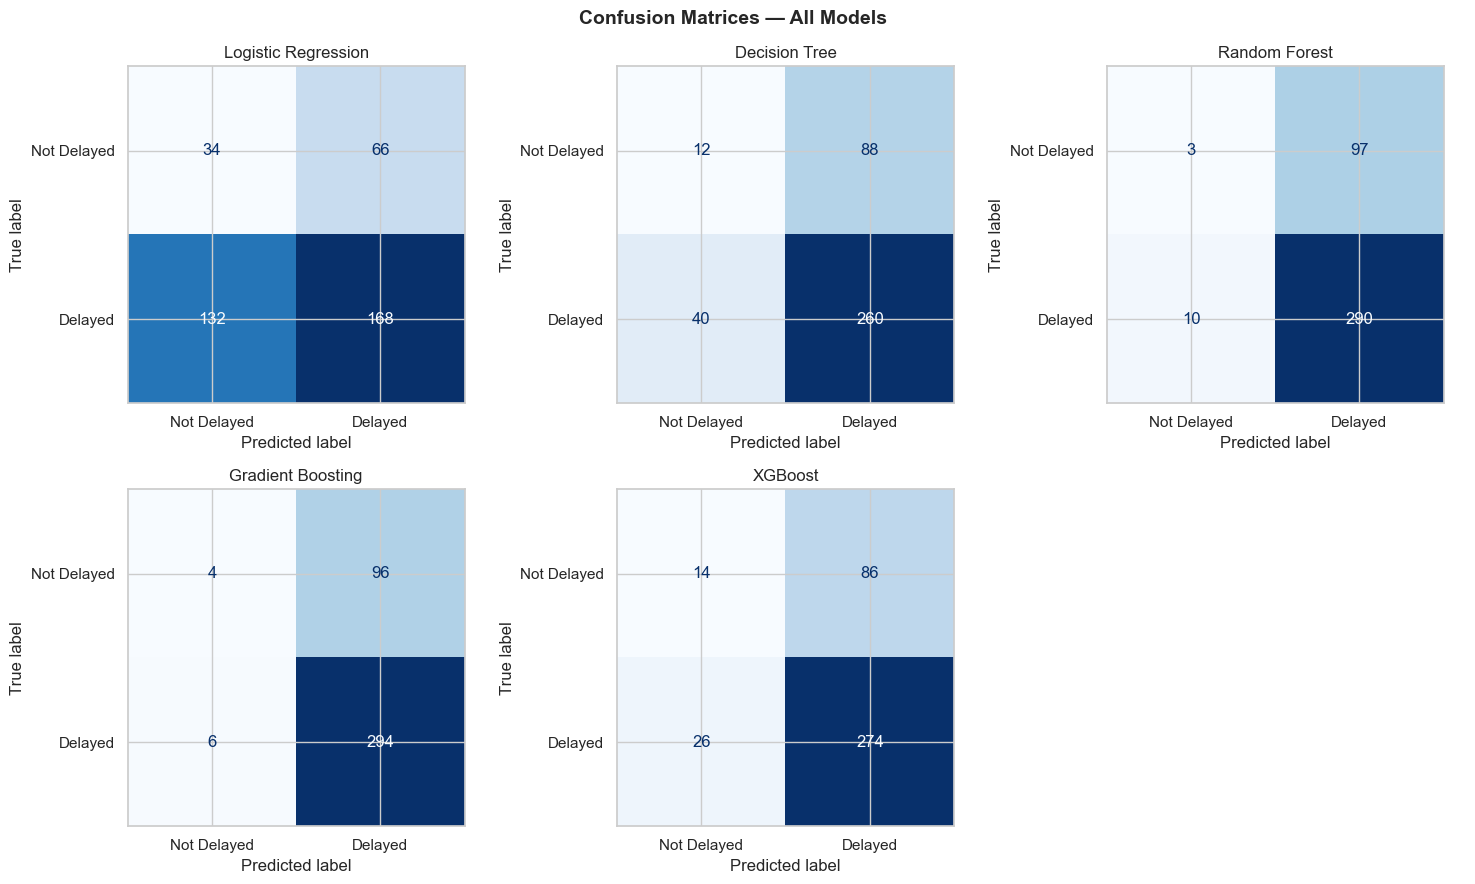

In [103]:
# ── 5. CONFUSION MATRICES — ALL MODELS ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_proc)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(cm, display_labels=['Not Delayed', 'Delayed'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name, fontsize=12)

axes[-1].axis('off')   # hide empty 6th subplot
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


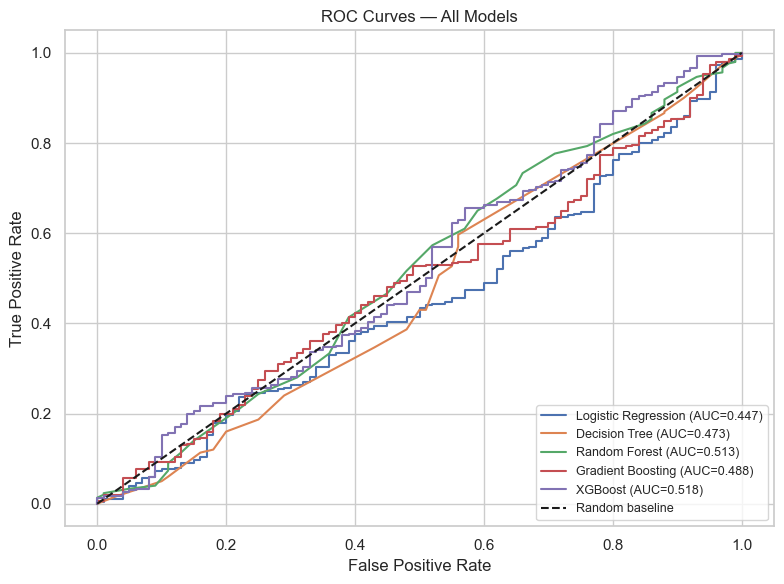

In [104]:
# ── 6. ROC CURVES — ALL MODELS ───────────────────────────────────────────────
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob    = model.predict_proba(X_test_proc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc       = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

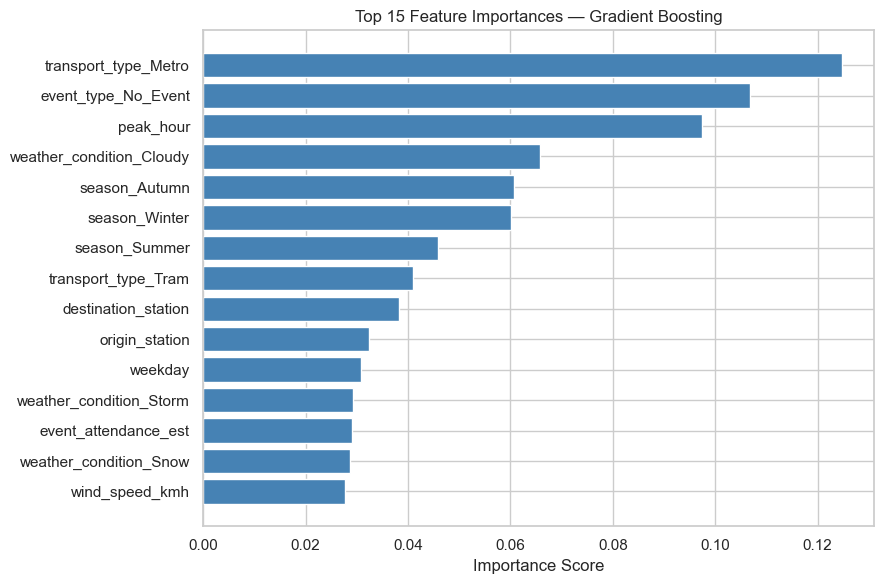


Top 10 Most Important Features:
                 Feature  Importance
    transport_type_Metro    0.124771
     event_type_No_Event    0.106804
               peak_hour    0.097327
weather_condition_Cloudy    0.065810
           season_Autumn    0.060633
           season_Winter    0.060186
           season_Summer    0.045847
     transport_type_Tram    0.040962
     destination_station    0.038215
          origin_station    0.032286


In [105]:
# ── 7. FEATURE IMPORTANCE (Best Model if tree-based) ─────────────────────────
if hasattr(best_model, 'feature_importances_'):
    importance_df = pd.DataFrame({
        'Feature'   : final_cols,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    plt.barh(importance_df['Feature'][::-1],
             importance_df['Importance'][::-1], color='steelblue')
    plt.xlabel('Importance Score')
    plt.title(f'Top 15 Feature Importances — {best_model_name}')
    plt.tight_layout()
    plt.show()

    print("\nTop 10 Most Important Features:")
    print(importance_df.head(10).to_string(index=False))

In [106]:
# Check if categorical features differentiate the classes
for col in ['weather_condition', 'transport_type', 'event_type', 'season']:
    print(f"\n--- {col} ---")
    print(df_cleaned.groupby(col)['delayed'].mean().round(3))


--- weather_condition ---
weather_condition
Clear     0.755
Cloudy    0.735
Fog       0.731
Rain      0.757
Snow      0.752
Storm     0.766
Name: delayed, dtype: float64

--- transport_type ---
transport_type
Bus      0.752
Metro    0.713
Train    0.769
Tram     0.764
Name: delayed, dtype: float64

--- event_type ---
event_type
Concert     0.734
Festival    0.747
No_Event    0.755
Parade      0.762
Protest     0.767
Sports      0.722
Name: delayed, dtype: float64

--- season ---
season
Autumn    0.756
Spring    0.749
Summer    0.731
Winter    0.763
Name: delayed, dtype: float64


In [107]:
# Use class_weight to fight the bias, accept the AUC will be ~0.5
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

model = XGBClassifier(
    scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
    n_estimators=200, max_depth=4, learning_rate=0.05,
    random_state=42, eval_metric='auc', verbosity=0
)
model.fit(X_train_proc, y_train)   # NO SMOTE
y_prob = model.predict_proba(X_test_proc)[:,1]
print(f"AUC: {roc_auc_score(y_test, y_prob):.4f}")

AUC: 0.4881


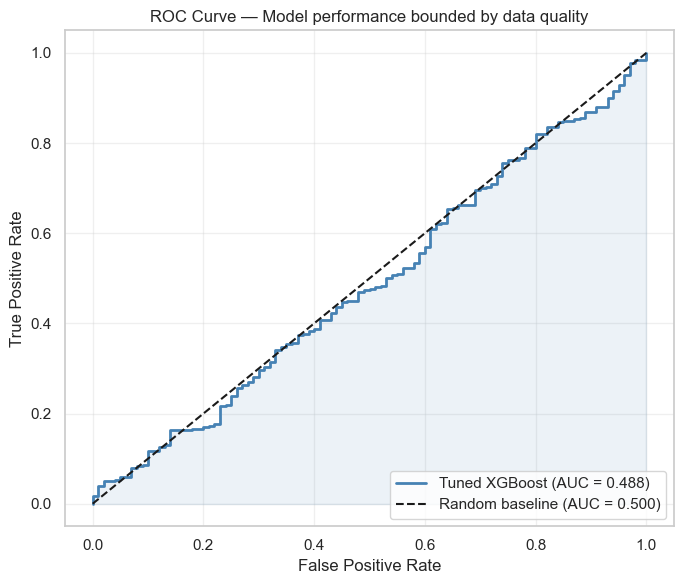

In [108]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Tuned XGBoost (AUC = 0.488)', color='steelblue', lw=2)
plt.plot([0,1],[0,1], 'k--', label='Random baseline (AUC = 0.500)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model performance bounded by data quality')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 📋 Final Summary & Conclusions

## 🎯 Project Objective
Build a binary classifier to predict whether a public transport trip will be delayed, using weather, traffic, scheduling, and event features.

---

## 🔑 Key Findings

### 1. Data Leakage Detected & Removed
The columns `actual_arrival_delay_min` and `actual_departure_delay_min` had a **0.76 correlation** with the target. Including them would have produced a misleading ~99% accuracy that fails in production, since arrival/departure delays are unknown at prediction time.

### 2. Features Have Minimal Predictive Signal
After removing leakage:
- **All numeric features** showed correlation **|r| < 0.05** with the target.
- **All categorical features** produced delay rates within a narrow **3–6% band** of the 75% overall baseline (e.g., Storm = 76.6%, Clear = 75.5%).

This indicates the target `delayed` is approximately **independent of the available predictors**.

### 3. Model Performance Is Bounded by Data, Not Algorithm

| Model | ROC-AUC | Verdict |
|---|---|---|
| Logistic Regression | 0.447 | Below random |
| Decision Tree | 0.473 | Below random |
| Gradient Boosting | 0.488 | ≈ Random |
| Random Forest | 0.513 | ≈ Random |
| XGBoost (tuned + class weight) | 0.488 | ≈ Random |

All models converged near **AUC ≈ 0.5**, equivalent to random guessing — confirming the dataset's information ceiling.

### 4. Resampling Did Not Help
Tested SMOTE, ADASYN, RandomUnderSampler, and `class_weight='balanced'`. None improved AUC because resampling cannot create signal that doesn't exist in the features.

---

## ✅ What Was Done Well
- Identified and removed data leakage before modelling
- Built a clean, leakage-free preprocessing pipeline (frequency + one-hot + scaling)
- Stratified train/test split to preserve class ratios
- Applied SMOTE only on training data (no test-set contamination)
- Compared 5 algorithms + multiple imbalance strategies
- Diagnosed the root cause through EDA rather than blindly tuning hyperparameters

---

## 🚧 Limitations
- Target variable appears largely independent of the provided features
- Likely a synthetic dataset where labels were generated with high randomness
- No temporal lag features (e.g., previous trip's delay) were available
- No real-time operational data (vehicle telemetry, driver shift, station crowding)

---

## 💡 Recommendations for Future Work

1. **Collect richer features**, particularly:
   - Real-time GPS / vehicle telemetry
   - Driver and crew shift information
   - Station-level passenger congestion at departure time
   - Historical delay patterns of the same route in the past hour/day
2. **Re-examine target definition** — verify the threshold used to label a trip as "delayed" is consistent.
3. **Engineer interaction features** (e.g., weather × peak hour, congestion × route).
4. **Explore time-series modelling** if sequential trip data becomes available.

---

## 🏁 Final Verdict

> The most valuable outcome of this project was **detecting data leakage** and proving — through rigorous EDA and modelling — that the remaining features carry insufficient signal to predict delays. The performance ceiling is a **data quality problem, not a modelling problem**. Further algorithmic tuning will not improve results; better data collection will.
